# Генерация лиц на CelebA: безусловный и условный WGAN-GP



In [ ]:
import sys

IS_COLAB = "google.colab" in sys.modules
if IS_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("kaggle") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kaggle"])


In [ ]:
import os
import csv
import math
import copy
import random
import subprocess
import contextlib
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFile

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from torchvision.utils import make_grid
from scipy import linalg
from tqdm.auto import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = True
torch.backends.cudnn.benchmark = True
try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

In [ ]:
SEED = 555
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = get_device()
DEVICE

device(type='cpu')

In [ ]:
def ensure_dir(p: Path) -> Path:
    p.mkdir(parents=True, exist_ok=True)
    return p

def try_colab_secret(name: str) -> str:
    try:
        from google.colab import userdata
        return userdata.get(name) or ""
    except Exception:
        return ""

def kaggle_auth() -> bool:
    if os.getenv("KAGGLE_USERNAME") and os.getenv("KAGGLE_KEY"):
        return True
    u = try_colab_secret("KAGGLE_USERNAME")
    k = try_colab_secret("KAGGLE_KEY")
    if u and k:
        os.environ["KAGGLE_USERNAME"] = u
        os.environ["KAGGLE_KEY"] = k
        return True
    return (Path.home() / ".kaggle" / "kaggle.json").exists()

def kaggle_download(dataset: str, out_dir: Path) -> Path:
    out_dir = ensure_dir(out_dir)
    marker = out_dir / ".kaggle_done"
    if marker.exists():
        return out_dir
    if not kaggle_auth():
        raise RuntimeError("Not found Kaggle credentials")
    subprocess.run(
        ["kaggle", "datasets", "download", "-d", dataset, "-p", str(out_dir), "--unzip"],
        check=True,
    )
    marker.write_text("ok", encoding="utf-8")
    return out_dir

def read_csv_rows(path: Path) -> List[Dict[str, str]]:
    with open(path, "r", newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))

def write_history_csv(path: Path, history: List[Dict[str, float]]) -> None:
    fieldnames = ["epoch", "g_loss", "d_loss", "wasserstein", "gp"]
    with open(path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in history:
            writer.writerow({
                "epoch": int(row["epoch"]),
                "g_loss": float(row["g_loss"]),
                "d_loss": float(row["d_loss"]),
                "wasserstein": float(row["wasserstein"]),
                "gp": float(row["gp"]),
            })

def read_history_csv(path: Path) -> List[Dict[str, float]]:
    if not path.exists():
        return []

    rows = read_csv_rows(path)
    out = []
    for row in rows:
        out.append({
            "epoch": int(row["epoch"]),
            "g_loss": float(row["g_loss"]),
            "d_loss": float(row["d_loss"]),
            "wasserstein": float(row["wasserstein"]),
            "gp": float(row["gp"]),
        })
    return out

def show_pil_grid(images: List[Image.Image], titles: Optional[List[str]] = None, cols: int = 4, size: Tuple[int, int] = (10, 10)):
    if not images:
        print("No images")
        return
    rows = math.ceil(len(images) / cols)
    plt.figure(figsize=size)
    for i, img in enumerate(images, start=1):
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.axis("off")
        if titles is not None and i - 1 < len(titles):
            plt.title(titles[i - 1], fontsize=8)
    plt.tight_layout()
    plt.show()

def plot_history(history: List[Dict[str, float]], title: str):
    if not history:
        print("History not available")
        return

    epochs = [row["epoch"] for row in history]
    g_loss = [row["g_loss"] for row in history]
    d_loss = [row["d_loss"] for row in history]
    wasserstein = [row["wasserstein"] for row in history]
    gp = [row["gp"] for row in history]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(epochs, g_loss, label="G")
    axes[0].plot(epochs, d_loss, label="D")
    axes[0].set_title("Generator / Critic loss")
    axes[0].legend()

    axes[1].plot(epochs, wasserstein)
    axes[1].set_title("Wasserstein estimate")

    axes[2].plot(epochs, gp)
    axes[2].set_title("Gradient penalty")

    for ax in axes:
        ax.set_xlabel("epoch")
        ax.grid(True, alpha=0.3)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [ ]:
ROOT = ensure_dir(Path("/content/drive/MyDrive/runs_celeba_gan_lab_working")) if IS_COLAB else ensure_dir(Path("./runs_celeba_gan_lab_working").resolve())
WORK = ensure_dir(Path("/content/work_celeba_gan_lab_working")) if IS_COLAB else ensure_dir((ROOT / "work").resolve())

RAW_DIR = ensure_dir(WORK / "kaggle_dataset")
RUNS_DIR = ensure_dir(ROOT / "runs")

KAGGLE_DATASET = "jessicali9530/celeba-dataset"
CONDITION_ATTR = "Male"

IMAGE_SIZE = 64
BBOX_MARGIN = 0.18
MAX_TRAIN_IMAGES = 60000
MAX_VAL_IMAGES = 6000
MAX_TEST_IMAGES = 6000

BATCH_SIZE = 128
NUM_WORKERS = 2
LATENT_DIM = 128
BASE_CH = 64

UNCOND_EPOCHS = 20
COND_EPOCHS = 12
N_CRITIC = 5
LAMBDA_GP = 10.0
LR_G = 1e-4
LR_D = 2e-4
BETAS = (0.0, 0.9)
EMA_BETA = 0.999

FID_NUM_SAMPLES = 1000
METRIC_BATCH_SIZE = 16

ROOT

PosixPath('/content/drive/MyDrive/runs_celeba_gan_lab_working')

## Подготовка датасета


In [ ]:
kaggle_download(KAGGLE_DATASET, RAW_DIR)

def pick_first_existing(candidates: List[Path]) -> Optional[Path]:
    for p in candidates:
        if p.exists():
            return p
    return None

def locate_celeba_paths(raw_dir: Path) -> Dict[str, Path]:
    img_dir = pick_first_existing([
        raw_dir / "img_align_celeba" / "img_align_celeba",
        raw_dir / "img_align_celeba",
    ])
    attr_path = pick_first_existing([
        raw_dir / "list_attr_celeba.csv",
        raw_dir / "list_attr_celeba.txt",
    ])
    partition_path = pick_first_existing([
        raw_dir / "list_eval_partition.csv",
        raw_dir / "list_eval_partition.txt",
    ])
    landmarks_path = pick_first_existing([
        raw_dir / "list_landmarks_align_celeba.csv",
        raw_dir / "list_landmarks_align_celeba.txt",
    ])

    if img_dir is None or attr_path is None or partition_path is None or landmarks_path is None:
        raise FileNotFoundError("Не удалось найти img_align_celeba / attr / partition / landmarks")

    return {
        "img_dir": img_dir,
        "attr": attr_path,
        "partition": partition_path,
        "landmarks": landmarks_path,
    }

CELEBA_PATHS = locate_celeba_paths(RAW_DIR)
CELEBA_PATHS

{'img_dir': PosixPath('/content/work_celeba_gan_lab_working/kaggle_dataset/img_align_celeba/img_align_celeba'),
 'attr': PosixPath('/content/work_celeba_gan_lab_working/kaggle_dataset/list_attr_celeba.csv'),
 'partition': PosixPath('/content/work_celeba_gan_lab_working/kaggle_dataset/list_eval_partition.csv'),
 'landmarks': PosixPath('/content/work_celeba_gan_lab_working/kaggle_dataset/list_landmarks_align_celeba.csv')}

In [ ]:
def read_attr_table(path: Path) -> Dict[str, Dict[str, int]]:
    out = {}
    for row in read_csv_rows(path):
        image_id = row["image_id"].strip()
        item = {}
        for k, v in row.items():
            if k == "image_id":
                continue
            item[k] = int(v)
        out[image_id] = item
    return out

def read_partition_table(path: Path) -> Dict[str, int]:
    out = {}
    for row in read_csv_rows(path):
        out[row["image_id"].strip()] = int(row["partition"])
    return out

def read_landmarks_table(path: Path) -> Dict[str, Dict[str, int]]:
    out = {}
    cols = [
        "lefteye_x", "lefteye_y",
        "righteye_x", "righteye_y",
        "nose_x", "nose_y",
        "leftmouth_x", "leftmouth_y",
        "rightmouth_x", "rightmouth_y",
    ]

    for row in read_csv_rows(path):
        image_id = row["image_id"].strip()
        out[image_id] = {k: int(row[k]) for k in cols}
    return out


def build_metadata_rows(paths: Dict[str, Path], attr_name: str) -> List[Dict[str, object]]:
    attrs = read_attr_table(paths["attr"])
    parts = read_partition_table(paths["partition"])
    landmarks = read_landmarks_table(paths["landmarks"])
    part_map = {0: "train", 1: "val", 2: "test"}

    rows = []
    for image_id, attr_row in attrs.items():
        src = paths["img_dir"] / image_id
        if not src.exists():
            continue
        if image_id not in parts or image_id not in landmarks:
            continue

        lmk = landmarks[image_id]
        label = 1 if int(attr_row[attr_name]) > 0 else 0

        row = {
            "image_id": image_id,
            "partition": int(parts[image_id]),
            "split": part_map[int(parts[image_id])],
            "label": label,
            "label_name": "male" if label == 1 else "female",
            "src_path": str(src.resolve()),
        }
        row.update({k: int(v) for k, v in lmk.items()})
        rows.append(row)

    rows = sorted(rows, key=lambda x: x["image_id"])
    return rows

meta_rows = build_metadata_rows(CELEBA_PATHS, CONDITION_ATTR)
len(meta_rows), meta_rows[0]

(202599,
 {'image_id': '000001.jpg',
  'partition': 0,
  'split': 'train',
  'label': 0,
  'label_name': 'female',
  'src_path': '/content/work_celeba_gan_lab_working/kaggle_dataset/img_align_celeba/img_align_celeba/000001.jpg',
  'lefteye_x': 69,
  'lefteye_y': 109,
  'righteye_x': 106,
  'righteye_y': 113,
  'nose_x': 77,
  'nose_y': 142,
  'leftmouth_x': 73,
  'leftmouth_y': 152,
  'rightmouth_x': 108,
  'rightmouth_y': 154})

In [ ]:
def sample_by_split(rows: List[Dict[str, object]], train_n: Optional[int], val_n: Optional[int], test_n: Optional[int]) -> List[Dict[str, object]]:
    by_split = {"train": [], "val": [], "test": []}
    for row in rows:
        by_split[row["split"]].append(dict(row))

    rng = random.Random(SEED)
    plan = {"train": train_n, "val": val_n, "test": test_n}
    out = []

    for split, limit in plan.items():
        sub = by_split.get(split, [])
        if limit is not None and len(sub) > limit:
            sub = rng.sample(sub, limit)
        sub = sorted(sub, key=lambda x: x["image_id"])
        out.extend(sub)

    return out

prep_rows = sample_by_split(meta_rows, MAX_TRAIN_IMAGES, MAX_VAL_IMAGES, MAX_TEST_IMAGES)

counts = {}
for row in prep_rows:
    counts[row["split"]] = counts.get(row["split"], 0) + 1
counts

{'train': 60000, 'val': 6000, 'test': 6000}

In [ ]:
def landmark_crop_box(rec: Dict[str, object], img_w: int, img_h: int):
    xs = np.array([
        int(rec["lefteye_x"]), int(rec["righteye_x"]), int(rec["nose_x"]),
        int(rec["leftmouth_x"]), int(rec["rightmouth_x"])
    ], dtype=np.float32)
    ys = np.array([
        int(rec["lefteye_y"]), int(rec["righteye_y"]), int(rec["nose_y"]),
        int(rec["leftmouth_y"]), int(rec["rightmouth_y"])
    ], dtype=np.float32)

    x_min, x_max = float(xs.min()), float(xs.max())
    y_min, y_max = float(ys.min()), float(ys.max())

    cx = (x_min + x_max) * 0.5
    cy = (y_min + y_max) * 0.5 + 0.08 * (y_max - y_min + 1.0)

    face_span_x = (x_max - x_min + 1.0)
    face_span_y = (y_max - y_min + 1.0)

    size = max(face_span_x * 2.2, face_span_y * 2.8)
    size = size * (1.0 + float(BBOX_MARGIN))
    half = size * 0.5

    x1 = int(round(cx - half))
    y1 = int(round(cy - half * 1.05))
    x2 = int(round(cx + half))
    y2 = int(round(cy + half * 0.95))

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img_w, x2)
    y2 = min(img_h, y2)

    if x2 <= x1 or y2 <= y1:
        side = min(img_w, img_h)
        x1 = (img_w - side) // 2
        y1 = (img_h - side) // 2
        x2 = x1 + side
        y2 = y1 + side

    return x1, y1, x2, y2

def crop_face_pil(rec: Dict[str, object], image_size: int = IMAGE_SIZE) -> Image.Image:
    src = Path(rec["src_path"])
    with Image.open(src) as img0:
        img = img0.convert("RGB")
    img_w, img_h = img.size

    x1, y1, x2, y2 = landmark_crop_box(rec, img_w, img_h)
    face = img.crop((x1, y1, x2, y2)).resize((image_size, image_size), Image.Resampling.BICUBIC)
    return face

face_rows = [dict(row) for row in prep_rows]
len(face_rows)

72000

In [ ]:
split_counts = {}
label_counts = {}
for row in face_rows:
    split_counts[row["split"]] = split_counts.get(row["split"], 0) + 1
    label_counts[row["label_name"]] = label_counts.get(row["label_name"], 0) + 1

print(split_counts)
print(label_counts)

{'train': 60000, 'val': 6000, 'test': 6000}
{'female': 41854, 'male': 30146}


In [ ]:
class FaceDataset(Dataset):
    def __init__(self, manifest_rows: List[Dict[str, object]], split: str, image_size: int = 64, augment: bool = False):
        self.rows = [row for row in manifest_rows if row["split"] == split]
        self.image_size = image_size

        tfm = []
        if augment:
            tfm += [transforms.RandomHorizontalFlip(p=0.5)]
        tfm += [
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ]
        self.transform = transforms.Compose(tfm)

    def __len__(self) -> int:
        return len(self.rows)

    def __getitem__(self, idx: int):
        row = self.rows[idx]
        img = crop_face_pil(row, image_size=self.image_size)
        x = self.transform(img)
        y = torch.tensor(int(row["label"]), dtype=torch.long)
        return x, y

train_ds = FaceDataset(face_rows, "train", image_size=IMAGE_SIZE, augment=True)
val_ds = FaceDataset(face_rows, "val", image_size=IMAGE_SIZE, augment=False)
test_ds = FaceDataset(face_rows, "test", image_size=IMAGE_SIZE, augment=False)

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": DEVICE.type == "cuda",
}

train_loader = DataLoader(train_ds, shuffle=True, drop_last=True, **loader_kwargs)
val_loader = DataLoader(val_ds, shuffle=False, drop_last=False, **loader_kwargs)
test_loader = DataLoader(test_ds, shuffle=False, drop_last=False, **loader_kwargs)

len(train_ds), len(val_ds), len(test_ds)

(60000, 6000, 6000)

## Модель: безусловный и условный WGAN-GP


In [ ]:
class Generator(nn.Module):
    def __init__(self, z_dim: int = 128, base_ch: int = 64, n_classes: int = 0):
        super().__init__()
        self.z_dim = z_dim
        self.base_ch = base_ch
        self.n_classes = n_classes

        self.fc = nn.Linear(z_dim, base_ch * 8 * 4 * 4)
        self.label_emb = nn.Embedding(n_classes, base_ch * 8) if n_classes > 0 else None

        self.net = nn.Sequential(
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_ch * 8, base_ch * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_ch * 2, base_ch, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_ch, 3, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z: torch.Tensor, y: Optional[torch.Tensor] = None) -> torch.Tensor:
        h = self.fc(z).view(z.size(0), self.base_ch * 8, 4, 4)
        if self.label_emb is not None:
            if y is None:
                raise ValueError("Conditional generator expects labels")
            cond = self.label_emb(y).view(z.size(0), self.base_ch * 8, 1, 1)
            h = h + cond
        return self.net(h)

class Critic(nn.Module):
    def __init__(self, base_ch: int = 64, n_classes: int = 0):
        super().__init__()
        self.base_ch = base_ch
        self.n_classes = n_classes

        self.features = nn.Sequential(
            nn.Conv2d(3, base_ch, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_ch, base_ch * 2, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_ch * 2, base_ch * 4, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_ch * 4, base_ch * 8, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.fc = nn.Linear(base_ch * 8 * 4 * 4, 1)
        self.label_proj = nn.Embedding(n_classes, base_ch * 8 * 4 * 4) if n_classes > 0 else None

    def forward(self, x: torch.Tensor, y: Optional[torch.Tensor] = None) -> torch.Tensor:
        h = self.features(x).view(x.size(0), -1)
        out = self.fc(h).view(-1)
        if self.label_proj is not None:
            if y is None:
                raise ValueError("Conditional critic expects labels")
            out = out + (self.label_proj(y) * h).sum(dim=1) / math.sqrt(h.size(1))
        return out

def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        nn.init.normal_(m.weight, 0.0, 0.02)
        if getattr(m, "bias", None) is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.zeros_(m.bias)

def build_generator(n_classes: int = 0) -> Generator:
    model = Generator(z_dim=LATENT_DIM, base_ch=BASE_CH, n_classes=n_classes)
    model.apply(weights_init)
    return model.to(DEVICE)

def build_critic(n_classes: int = 0) -> Critic:
    model = Critic(base_ch=BASE_CH, n_classes=n_classes)
    model.apply(weights_init)
    return model.to(DEVICE)

def sample_noise(bs: int, z_dim: int, device: torch.device) -> torch.Tensor:
    return torch.randn(bs, z_dim, device=device)

@torch.no_grad()
def copy_shared_weights(src: nn.Module, dst: nn.Module):
    src_sd = src.state_dict()
    dst_sd = dst.state_dict()
    for k, v in src_sd.items():
        if k in dst_sd and dst_sd[k].shape == v.shape:
            dst_sd[k].copy_(v)
    dst.load_state_dict(dst_sd)

In [ ]:
def gradient_penalty(critic: nn.Module, real: torch.Tensor, fake: torch.Tensor, y: Optional[torch.Tensor] = None) -> torch.Tensor:
    b = real.size(0)
    alpha = torch.rand(b, 1, 1, 1, device=real.device)
    inter = alpha * real + (1.0 - alpha) * fake
    inter.requires_grad_(True)

    score = critic(inter, y)
    grad = torch.autograd.grad(
        outputs=score,
        inputs=inter,
        grad_outputs=torch.ones_like(score),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

    grad = grad.view(b, -1)
    gp = ((grad.norm(2, dim=1) - 1.0) ** 2).mean()
    return gp

@torch.no_grad()
def update_ema(ema_model: nn.Module, model: nn.Module, beta: float = 0.999) -> None:
    for p_ema, p in zip(ema_model.parameters(), model.parameters()):
        p_ema.data.mul_(beta).add_(p.data, alpha=1.0 - beta)
    for b_ema, b in zip(ema_model.buffers(), model.buffers()):
        b_ema.copy_(b)

@torch.no_grad()
def tensor_to_display(x: torch.Tensor) -> torch.Tensor:
    return x.clamp(-1, 1).mul(0.5).add(0.5)

def train_wgan_gp(
    generator: nn.Module,
    critic: nn.Module,
    train_loader: DataLoader,
    run_dir: Path,
    epochs: int,
    conditional: bool = False,
) -> Tuple[nn.Module, nn.Module, List[Dict[str, float]]]:
    run_dir = ensure_dir(run_dir)

    g = generator.to(DEVICE)
    d = critic.to(DEVICE)
    g_ema = copy.deepcopy(g).eval()

    opt_g = torch.optim.Adam(g.parameters(), lr=LR_G, betas=BETAS)
    opt_d = torch.optim.Adam(d.parameters(), lr=LR_D, betas=BETAS)

    history = []

    for epoch in range(1, epochs + 1):
        g.train()
        d.train()

        epoch_g = 0.0
        epoch_d = 0.0
        epoch_w = 0.0
        epoch_gp = 0.0
        steps = 0

        pbar = tqdm(train_loader, desc=f"epoch {epoch}/{epochs}")
        for real, y in pbar:
            real = real.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            bs = real.size(0)

            for _ in range(N_CRITIC):
                z = sample_noise(bs, LATENT_DIM, DEVICE)
                with torch.no_grad():
                    fake = g(z, y if conditional else None)

                real_score = d(real, y if conditional else None)
                fake_score = d(fake, y if conditional else None)
                gp = gradient_penalty(d, real, fake, y if conditional else None)
                d_loss = fake_score.mean() - real_score.mean() + LAMBDA_GP * gp

                opt_d.zero_grad(set_to_none=True)
                d_loss.backward()
                opt_d.step()

            z = sample_noise(bs, LATENT_DIM, DEVICE)
            fake = g(z, y if conditional else None)
            g_loss = -d(fake, y if conditional else None).mean()

            opt_g.zero_grad(set_to_none=True)
            g_loss.backward()
            opt_g.step()
            update_ema(g_ema, g, beta=EMA_BETA)

            epoch_g += float(g_loss.item())
            epoch_d += float(d_loss.item())
            epoch_w += float((real_score.mean() - fake_score.mean()).item())
            epoch_gp += float(gp.item())
            steps += 1

            pbar.set_postfix({
                "g": f"{epoch_g / steps:.3f}",
                "d": f"{epoch_d / steps:.3f}",
                "w": f"{epoch_w / steps:.3f}",
                "gp": f"{epoch_gp / steps:.3f}",
            })

        history.append({
            "epoch": epoch,
            "g_loss": epoch_g / max(1, steps),
            "d_loss": epoch_d / max(1, steps),
            "wasserstein": epoch_w / max(1, steps),
            "gp": epoch_gp / max(1, steps),
        })

        write_history_csv(run_dir / "history.csv", history)

        torch.save(g.state_dict(), run_dir / "generator_last.pt")
        torch.save(g_ema.state_dict(), run_dir / "generator_ema_last.pt")
        torch.save(d.state_dict(), run_dir / "critic_last.pt")

    return g, g_ema, history

## Метрики: FID и IS


In [ ]:
class InceptionMetrics:
    def __init__(self, device: torch.device):
        self.device = device
        self.model = self._build_model().to(device).eval()
        self._features = None
        self._hook = self.model.avgpool.register_forward_hook(self._hook_fn)

    def _build_model(self):
        try:
            weights = models.Inception_V3_Weights.DEFAULT
            model = models.inception_v3(weights=weights, transform_input=False)
        except Exception:
            model = models.inception_v3(pretrained=True, transform_input=False)
        model.eval()
        return model

    def _hook_fn(self, module, inputs, output):
        self._features = output.flatten(1)

    @torch.no_grad()
    def process_batch(self, x: torch.Tensor) -> Tuple[np.ndarray, np.ndarray]:
        x = x.to(self.device, non_blocking=(self.device.type == "cuda"))
        x = F.interpolate(x, size=(299, 299), mode="bilinear", align_corners=False)

        amp_ctx = (
            torch.autocast(device_type="cuda", dtype=torch.float16)
            if self.device.type == "cuda"
            else contextlib.nullcontext()
        )

        with torch.inference_mode():
            with amp_ctx:
                out = self.model(x)

        if hasattr(out, "logits"):
            logits = out.logits
        elif isinstance(out, tuple):
            logits = out[0]
        else:
            logits = out

        feats = self._features
        feats_np = feats.detach().float().cpu().numpy()
        logits_np = logits.detach().float().cpu().numpy()
        return feats_np, logits_np

    def close(self):
        if self._hook is not None:
            self._hook.remove()

def compute_fid(real_feats: np.ndarray, fake_feats: np.ndarray) -> float:
    mu1 = real_feats.mean(axis=0)
    mu2 = fake_feats.mean(axis=0)

    sigma1 = np.cov(real_feats, rowvar=False)
    sigma2 = np.cov(fake_feats, rowvar=False)

    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff @ diff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return float(np.real(fid))

def compute_inception_score(fake_logits: np.ndarray, splits: int = 10) -> Tuple[float, float]:
    probs = torch.from_numpy(fake_logits).softmax(dim=1).numpy()
    n = probs.shape[0]
    splits = max(1, min(splits, n))
    split_size = max(1, n // splits)
    scores = []

    for i in range(splits):
        start = i * split_size
        end = n if i == splits - 1 else min(n, (i + 1) * split_size)
        pyx = probs[start:end]
        if len(pyx) == 0:
            continue
        py = pyx.mean(axis=0, keepdims=True)
        kl = pyx * (np.log(pyx + 1e-12) - np.log(py + 1e-12))
        scores.append(np.exp(kl.sum(axis=1).mean()))

    return float(np.mean(scores)), float(np.std(scores))

@torch.no_grad()
def get_real_features(metric: InceptionMetrics, loader: DataLoader, n_samples: int) -> np.ndarray:
    feats_all = []
    total = 0
    for x, _ in tqdm(loader, total=math.ceil(n_samples / loader.batch_size), desc="real feats"):
        if total >= n_samples:
            break
        take = min(x.size(0), n_samples - total)
        feats, _ = metric.process_batch(x[:take])
        feats_all.append(feats)
        total += take
    return np.concatenate(feats_all, axis=0)

@torch.no_grad()
def get_fake_features_logits(
    metric: InceptionMetrics,
    generator: nn.Module,
    n_samples: int,
    conditional: bool = False,
    fixed_label: Optional[int] = None,
) -> Tuple[np.ndarray, np.ndarray]:
    generator.eval()

    feats_all = []
    logits_all = []
    total = 0

    pbar = tqdm(total=n_samples, desc="fake feats")
    while total < n_samples:
        cur_bs = min(METRIC_BATCH_SIZE, n_samples - total)
        z = sample_noise(cur_bs, LATENT_DIM, DEVICE)

        if conditional:
            if fixed_label is None:
                y = torch.randint(0, 2, (cur_bs,), device=DEVICE)
            else:
                y = torch.full((cur_bs,), int(fixed_label), device=DEVICE, dtype=torch.long)
        else:
            y = None

        fake = generator(z, y)
        feats, logits = metric.process_batch(fake)
        feats_all.append(feats)
        logits_all.append(logits)

        total += cur_bs
        pbar.update(cur_bs)

    pbar.close()
    return np.concatenate(feats_all, axis=0), np.concatenate(logits_all, axis=0)

@torch.no_grad()
def evaluate_fid_is(
    generator: nn.Module,
    real_loader: DataLoader,
    n_samples: int,
    conditional: bool = False,
    fixed_label: Optional[int] = None,
) -> Dict[str, float]:
    metric = InceptionMetrics(DEVICE)
    real_feats = get_real_features(metric, real_loader, n_samples)
    fake_feats, fake_logits = get_fake_features_logits(
        metric,
        generator,
        n_samples=n_samples,
        conditional=conditional,
        fixed_label=fixed_label,
    )
    metric.close()
    del metric

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    fid = compute_fid(real_feats, fake_feats)
    is_mean, is_std = compute_inception_score(fake_logits)

    return {
        "n_samples": int(n_samples),
        "fid": float(fid),
        "is_mean": float(is_mean),
        "is_std": float(is_std),
    }

def make_label_subset_loader(dataset: FaceDataset, label: int) -> DataLoader:
    idx = [i for i, row in enumerate(dataset.rows) if int(row["label"]) == label]
    subset = Subset(dataset, idx)
    return DataLoader(
        subset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
    )

## Обучение безусловной модели


In [ ]:
UNCOND_RUN_DIR = ensure_dir(RUNS_DIR / "wgan_gp_unconditional")

G_UNCOND_LAST = UNCOND_RUN_DIR / "generator_last.pt"
G_UNCOND_EMA_LAST = UNCOND_RUN_DIR / "generator_ema_last.pt"
D_UNCOND_LAST = UNCOND_RUN_DIR / "critic_last.pt"
HIST_UNCOND = UNCOND_RUN_DIR / "history.csv"

hist_uncond = []

if G_UNCOND_LAST.exists() and G_UNCOND_EMA_LAST.exists() and D_UNCOND_LAST.exists():
    print("Loading saved unconditional checkpoint...")
    G_uncond = build_generator(n_classes=0)
    G_uncond.load_state_dict(torch.load(G_UNCOND_LAST, map_location="cpu"))
    G_uncond = G_uncond.to(DEVICE).eval()

    G_uncond_ema = build_generator(n_classes=0)
    G_uncond_ema.load_state_dict(torch.load(G_UNCOND_EMA_LAST, map_location="cpu"))
    G_uncond_ema = G_uncond_ema.to(DEVICE).eval()

    D_uncond = build_critic(n_classes=0)
    D_uncond.load_state_dict(torch.load(D_UNCOND_LAST, map_location="cpu"))
    D_uncond = D_uncond.to(DEVICE).eval()

    hist_uncond = read_history_csv(HIST_UNCOND)
else:
    print("Training unconditional model from scratch...")
    G_uncond = build_generator(n_classes=0)
    D_uncond = build_critic(n_classes=0)

    G_uncond, G_uncond_ema, hist_uncond = train_wgan_gp(
        G_uncond,
        D_uncond,
        train_loader,
        UNCOND_RUN_DIR,
        epochs=UNCOND_EPOCHS,
        conditional=False,
    )

Loading saved unconditional checkpoint...


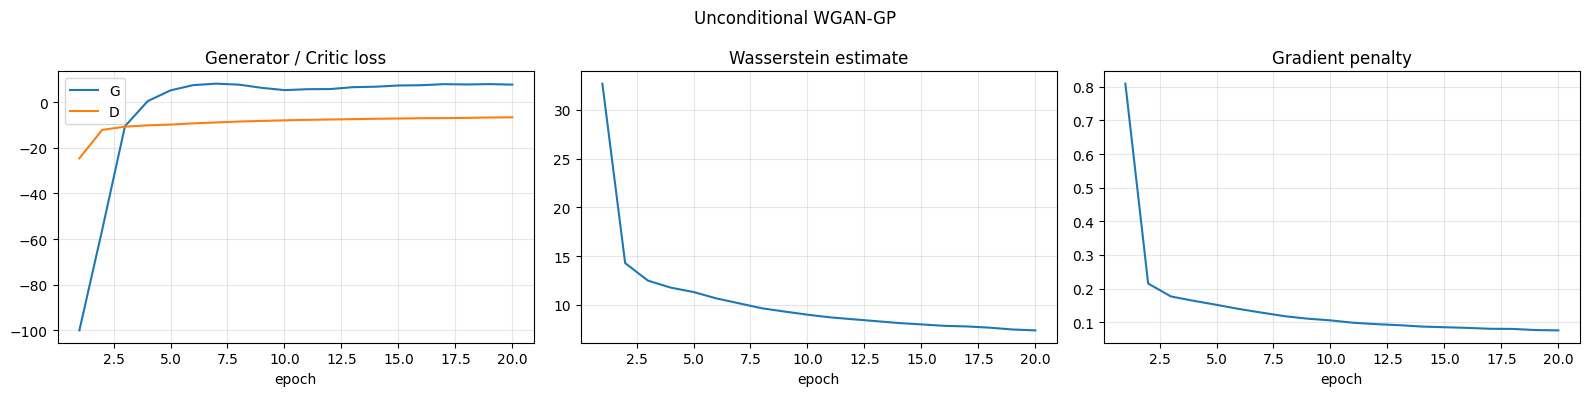

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 133MB/s]


real feats:   0%|          | 0/8 [00:00<?, ?it/s]

fake feats:   0%|          | 0/1000 [00:00<?, ?it/s]

/tmp/ipykernel_818/860712397.py:59: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)


{'n_samples': 1000,
 'fid': 60.99171128932205,
 'is_mean': 2.0305848121643066,
 'is_std': 0.16788294911384583}

In [ ]:
plot_history(hist_uncond, "Unconditional WGAN-GP")

import gc

if "D_uncond" in globals():
    del D_uncond
if "G_uncond" in globals():
    del G_uncond
gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

if "G_uncond_ema" not in globals():
    G_uncond_ema = build_generator(n_classes=0)
    G_uncond_ema.load_state_dict(torch.load(UNCOND_RUN_DIR / "generator_ema_last.pt", map_location="cpu"))
    G_uncond_ema = G_uncond_ema.to(DEVICE).eval()

uncond_metrics = evaluate_fid_is(
    G_uncond_ema,
    test_loader,
    n_samples=min(FID_NUM_SAMPLES, len(test_ds)),
    conditional=False,
)
uncond_metrics

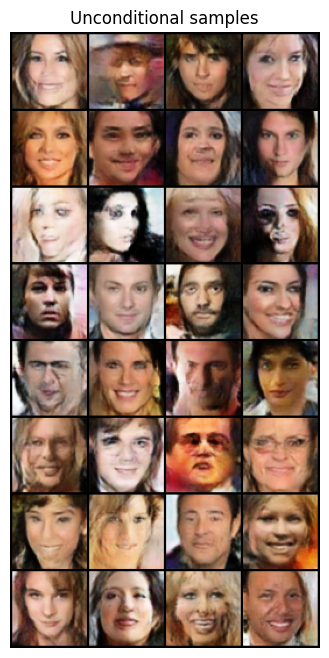

In [ ]:
@torch.no_grad()
def generate_unconditional_grid(generator: nn.Module, title: str):
    generator.eval()
    z = sample_noise(32, LATENT_DIM, DEVICE)
    x = generator(z)
    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(make_grid(tensor_to_display(x).cpu(), nrow=4).numpy(), (1, 2, 0)))
    plt.axis("off")
    plt.title(title)
    plt.show()

generate_unconditional_grid(G_uncond_ema, title="Unconditional samples")

## Переход к условной генерации по атрибуту `Male`


In [ ]:
import gc

COND_RUN_DIR = ensure_dir(RUNS_DIR / "wgan_gp_conditional_male")

G_COND_LAST = COND_RUN_DIR / "generator_last.pt"
G_COND_EMA_LAST = COND_RUN_DIR / "generator_ema_last.pt"
D_COND_LAST = COND_RUN_DIR / "critic_last.pt"
HIST_COND = COND_RUN_DIR / "history.csv"

hist_cond = []

if G_COND_LAST.exists() and G_COND_EMA_LAST.exists() and D_COND_LAST.exists():
    print("Loading saved conditional checkpoint...")
    G_cond = build_generator(n_classes=2)
    G_cond.load_state_dict(torch.load(G_COND_LAST, map_location="cpu"))
    G_cond = G_cond.to(DEVICE).eval()

    G_cond_ema = build_generator(n_classes=2)
    G_cond_ema.load_state_dict(torch.load(G_COND_EMA_LAST, map_location="cpu"))
    G_cond_ema = G_cond_ema.to(DEVICE).eval()

    D_cond = build_critic(n_classes=2)
    D_cond.load_state_dict(torch.load(D_COND_LAST, map_location="cpu"))
    D_cond = D_cond.to(DEVICE).eval()

    hist_cond = read_history_csv(HIST_COND)
else:
    print("Training conditional model from scratch...")

    if "G_uncond_ema" not in globals():
        G_uncond_ema = build_generator(n_classes=0)
        G_uncond_ema.load_state_dict(torch.load(UNCOND_RUN_DIR / "generator_ema_last.pt", map_location="cpu"))
        G_uncond_ema = G_uncond_ema.to(DEVICE).eval()

    D_uncond_init = build_critic(n_classes=0)
    D_uncond_init.load_state_dict(torch.load(UNCOND_RUN_DIR / "critic_last.pt", map_location="cpu"))
    D_uncond_init = D_uncond_init.to(DEVICE).eval()

    G_cond = build_generator(n_classes=2)
    D_cond = build_critic(n_classes=2)

    copy_shared_weights(G_uncond_ema, G_cond)
    copy_shared_weights(D_uncond_init, D_cond)

    del D_uncond_init
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    G_cond = G_cond.to(DEVICE)
    D_cond = D_cond.to(DEVICE)

    G_cond, G_cond_ema, hist_cond = train_wgan_gp(
        G_cond,
        D_cond,
        train_loader,
        COND_RUN_DIR,
        epochs=COND_EPOCHS,
        conditional=True,
    )

Loading saved conditional checkpoint...


In [23]:
plot_history(hist_cond, "Conditional WGAN-GP")

import gc

if "D_cond" in globals():
    del D_cond
if "G_cond" in globals():
    del G_cond
if "G_uncond_ema" in globals():
    del G_uncond_ema
gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

if "G_cond_ema" not in globals():
    G_cond_ema = build_generator(n_classes=2)
    G_cond_ema.load_state_dict(torch.load(COND_RUN_DIR / "generator_ema_last.pt", map_location="cpu"))
    G_cond_ema = G_cond_ema.to(DEVICE).eval()

test_female_loader = make_label_subset_loader(test_ds, label=0)
test_male_loader = make_label_subset_loader(test_ds, label=1)

cond_metrics_all = evaluate_fid_is(
    G_cond_ema,
    test_loader,
    n_samples=min(FID_NUM_SAMPLES, len(test_ds)),
    conditional=True,
)
cond_metrics_female = evaluate_fid_is(
    G_cond_ema,
    test_female_loader,
    n_samples=min(FID_NUM_SAMPLES // 2, len(test_female_loader.dataset)),
    conditional=True,
    fixed_label=0,
)
cond_metrics_male = evaluate_fid_is(
    G_cond_ema,
    test_male_loader,
    n_samples=min(FID_NUM_SAMPLES // 2, len(test_male_loader.dataset)),
    conditional=True,
    fixed_label=1,
)

cond_metrics_rows = [
    {"split": "all", **cond_metrics_all},
    {"split": "female", **cond_metrics_female},
    {"split": "male", **cond_metrics_male},
]
cond_metrics_rows

History not available


real feats:   0%|          | 0/8 [00:00<?, ?it/s]

fake feats:   0%|          | 0/1000 [00:00<?, ?it/s]

/tmp/ipykernel_818/860712397.py:59: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)


real feats:   0%|          | 0/4 [00:00<?, ?it/s]

fake feats:   0%|          | 0/500 [00:00<?, ?it/s]

real feats:   0%|          | 0/4 [00:00<?, ?it/s]

fake feats:   0%|          | 0/500 [00:00<?, ?it/s]

[{'split': 'all',
  'n_samples': 1000,
  'fid': 53.517323039813505,
  'is_mean': 2.2241663932800293,
  'is_std': 0.1208251491189003},
 {'split': 'female',
  'n_samples': 500,
  'fid': 56.92991882427948,
  'is_mean': 1.8841946125030518,
  'is_std': 0.0848439559340477},
 {'split': 'male',
  'n_samples': 500,
  'fid': 76.62380200875378,
  'is_mean': 2.1632611751556396,
  'is_std': 0.18315133452415466}]

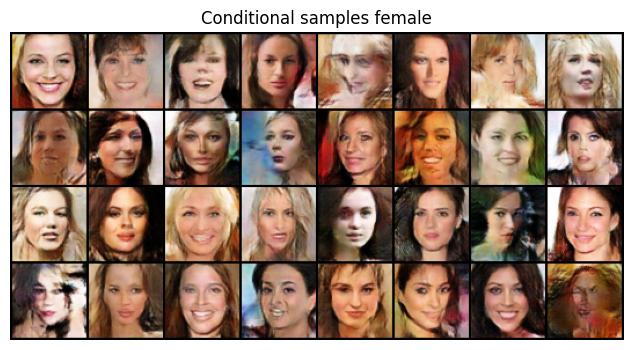

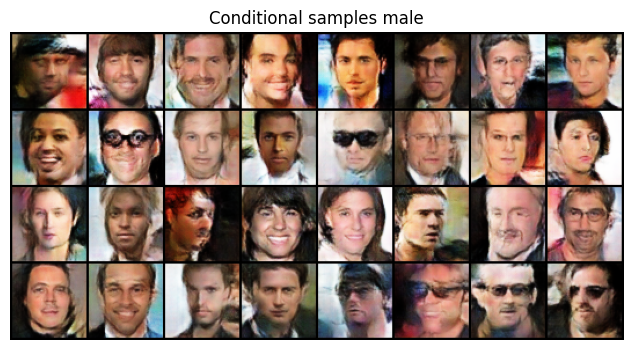

In [ ]:
@torch.no_grad()
def generate_condition_grid(generator: nn.Module, label: int, title: str):
    generator.eval()
    z = sample_noise(32, LATENT_DIM, DEVICE)
    y = torch.full((32,), label, device=DEVICE, dtype=torch.long)
    x = generator(z, y)
    plt.figure(figsize=(8, 4))
    plt.imshow(np.transpose(make_grid(tensor_to_display(x).cpu(), nrow=8).numpy(), (1, 2, 0)))
    plt.axis("off")
    plt.title(title)
    plt.show()

generate_condition_grid(G_cond_ema, label=0, title="Conditional samples female")
generate_condition_grid(G_cond_ema, label=1, title="Conditional samples male")

## Вывод

Условная WGAN-GP показала лучшие результаты по сравнению с безусловной моделью: общий FID снизился, а IS вырос. Это говорит о том, что добавление условного признака улучшило качество генерации.
При этом качество по классам оказалось неоднородным – более слабое моделирование мужского класса. Возможные причины — дисбаланс данных, недостаточное число эпох.